Dataset from Kaggle is now loaded onto colab Files and will be unzipped.

#Import Python Libraries

In [23]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing  import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, recall_score, precision_score,classification_report, f1_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


#Data Load
Data is loaded in Python.

In [42]:
url = "https://raw.githubusercontent.com/Sponono/RPDA8412/baed8f70f9ecbd5e6bc29d9d9a4b78b073998dd6/credit_risk_dataset.csv"
df = pd.read_csv(url)

df.head()

,Column1,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,...,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk,risk_category
0,CUST_00000,58,Male,Unemployed,58137.75119,115,524.679407,1,171.342369,49,...,1,539,5,14435.42344,2,0,0,15510.576880,1,High Risk
1,CUST_00001,48,Male,Self-Employed,26174.92283,32,2635.203357,1,985.607164,1,...,2,494,5,11263.09934,2,0,0,14819.436500,1,High Risk
2,CUST_00002,34,Other,Unemployed,75566.83726,14,2334.341061,9,994.310119,42,...,6,437,3,15017.14413,5,0,0,10909.806510,1,High Risk
3,CUST_00003,62,Male,Self-Employed,35197.96152,179,2425.384332,10,366.115346,4,...,7,809,1,12626.13848,2,0,0,500.000000,0,Low Risk
4,CUST_00004,27,Female,Self-Employed,12136.99835,225,10.000000,8,786.752258,16,...,3,522,1,13576.70432,4,0,0,9514.591618,1,High Risk


####Data Structure
This step focuses on understanding and validating the dataset structure. The data structure is confirmed by pulling the first 5 records of the dataset. (GeeksforGeeks, 2026)

In [43]:
df.head()

,Column1,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,...,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk,risk_category
0,CUST_00000,58,Male,Unemployed,58137.75119,115,524.679407,1,171.342369,49,...,1,539,5,14435.42344,2,0,0,15510.576880,1,High Risk
1,CUST_00001,48,Male,Self-Employed,26174.92283,32,2635.203357,1,985.607164,1,...,2,494,5,11263.09934,2,0,0,14819.436500,1,High Risk
2,CUST_00002,34,Other,Unemployed,75566.83726,14,2334.341061,9,994.310119,42,...,6,437,3,15017.14413,5,0,0,10909.806510,1,High Risk
3,CUST_00003,62,Male,Self-Employed,35197.96152,179,2425.384332,10,366.115346,4,...,7,809,1,12626.13848,2,0,0,500.000000,0,Low Risk
4,CUST_00004,27,Female,Self-Employed,12136.99835,225,10.000000,8,786.752258,16,...,3,522,1,13576.70432,4,0,0,9514.591618,1,High Risk


####Size of Data
This step helps understand the number of rows (observations) and columns (features) in the dataset. This gives an overview of the dataset's size and structure. (GeeksforGeeks, 2026)

In [ ]:
df.shape

(5000, 23)

There are 5000 rows (observations) and 23 columns

####Data Overview
This step provides an overview of the dataset by displaying the number of records in each column, type of data, whether any values are missing and how much memory the dataset uses.(GeeksforGeeks, 2026)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Column1                     5000 non-null   object 
 1   age                         5000 non-null   int64  
 2   gender                      5000 non-null   object 
 3   employment_status           5000 non-null   object 
 4   annual_income               5000 non-null   float64
 5   account_age_months          5000 non-null   int64  
 6   avg_monthly_balance         5000 non-null   float64
 7   num_deposits_per_month      5000 non-null   int64  
 8   avg_deposit_amount          5000 non-null   float64
 9   debit_card_usage_frequency  5000 non-null   int64  
 10  debit_card_spending         5000 non-null   float64
 11  mobile_banking_logins       5000 non-null   int64  
 12  online_transfer_frequency   5000 non-null   int64  
 13  atm_withdrawal_frequency    5000 

#Data Cleaning
Null values and duplicates are checked to ensure data completeness and prevent biased or misleading results, and data types are verified to confirm that each variable is correctly classified for accurate analysis.

In [ ]:
df.isnull().sum()

,0
Column1,0
age,0
gender,0
employment_status,0
annual_income,0
account_age_months,0
avg_monthly_balance,0
num_deposits_per_month,0
avg_deposit_amount,0
debit_card_usage_frequency,0


The above results confirm that there are no Null values in the dataset.

In [ ]:
df.duplicated().sum()

np.int64(0)

The above results confirm that there are no duplicated records in the dataset.

In [ ]:
df.isna().mean().sort_values(ascending=False).head(20)


,0
Column1,0.0
age,0.0
gender,0.0
employment_status,0.0
annual_income,0.0
account_age_months,0.0
avg_monthly_balance,0.0
num_deposits_per_month,0.0
avg_deposit_amount,0.0
debit_card_usage_frequency,0.0


The above results confirm that there are no missing values in the dataset.

#####Removing unnecessary columns
Deleting Column1 and risk_category because they are not numerical columns, Column1 is an unique identifier in the dataset, and the risk_category is the categorical column for credit_risk. These 2 columns will not be used in the analysis.

In [6]:
df = df.drop(columns=['Column1', 'risk_category'])

####Data Encoding
Categorical variables such as ‘gender’ and ‘employment_status’ are converted into numeric formats using one-hot encoder

In [7]:
# Female=0 and Male=1
gender_categories = ['Female', 'Male', 'Other']
# Employed=0, Self-Employed=1, Unemployed=2
employment_categories = ['Employed', 'Self-Employed', 'Unemployed']

df['gender'] = df['gender'].astype(str)
df['employment_status'] = df['employment_status'].astype(str)

encoder = OrdinalEncoder(
    categories=[gender_categories, employment_categories],
    dtype=int )

df[['gender', 'employment_status']] = encoder.fit_transform(df[['gender', 'employment_status']])

df['employment_status'] = df['employment_status'] + 1

In [8]:
df.head()

,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,...,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
0,58,1,3,58137.75119,115,524.679407,1,171.342369,49,768.877511,...,16,1,539,5,14435.42344,2,0,0,15510.576880,1
1,48,1,2,26174.92283,32,2635.203357,1,985.607164,1,580.287786,...,1,2,494,5,11263.09934,2,0,0,14819.436500,1
2,34,2,3,75566.83726,14,2334.341061,9,994.310119,42,564.013508,...,5,6,437,3,15017.14413,5,0,0,10909.806510,1
3,62,1,2,35197.96152,179,2425.384332,10,366.115346,4,838.489200,...,7,7,809,1,12626.13848,2,0,0,500.000000,0
4,27,0,2,12136.99835,225,10.000000,8,786.752258,16,462.495522,...,16,3,522,1,13576.70432,4,0,0,9514.591618,1


###Train Model
The dataset is split into training and testing sets, using an 80/20 split, to enable proper model training and validation on unseen data.

In [9]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=['credit_risk'])
y = df['credit_risk']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


###Preprocessing Pipelines

Scaling numerical to ensure that variables with different magnitudes are placed on a comparable scale. This process transforms the data to have a mean of 0 and a standard deviation of 1, which helps improve the performance, stability, and efficiency of machine learning models.

In [10]:
# Identifying numeric (continuous) variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Removing target
if 'credit_risk' in num_cols:
    num_cols.remove('credit_risk')

# Identifying categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [11]:
#Scaling data for Logistic Regression and XG Boost
preprocess_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough'
)


In [12]:
#Non_Scaling data for Decision Tree and Random Forest
preprocess_noscale = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols)
    ],
    remainder='passthrough'
)

#Feature Selection
Feature Selection involves identifying and selecting the most relevant features (variables) that contribute to the prediction of the target variable. Correlation analysis, univariate statistical tests such as Confusion Matric, ANOVA F‑tests, and Recursive Feature Elimination (RFE) will be used to identify the most relevant predictors and remove variables that do not meaningfully contribute to the linear regression model.

###ANOVA F-Test

In [13]:
from sklearn.feature_selection import SelectKBest, f_classif

anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(x_train, y_train)

anova_scores = pd.DataFrame({
    'feature': x_train.columns,
    'score': anova_selector.scores_
}).sort_values(by='score', ascending=False)

anova_scores

,feature,score
16,late_payment_count,1262.806183
13,credit_score,1020.143786
17,loan_default_history,132.244947
18,fraud_flag,35.873918
9,debit_card_spending,3.469232
19,loan_application_amount,1.766945
12,atm_withdrawal_frequency,1.757826
6,num_deposits_per_month,1.274507
8,debit_card_usage_frequency,0.920941
1,gender,0.384123


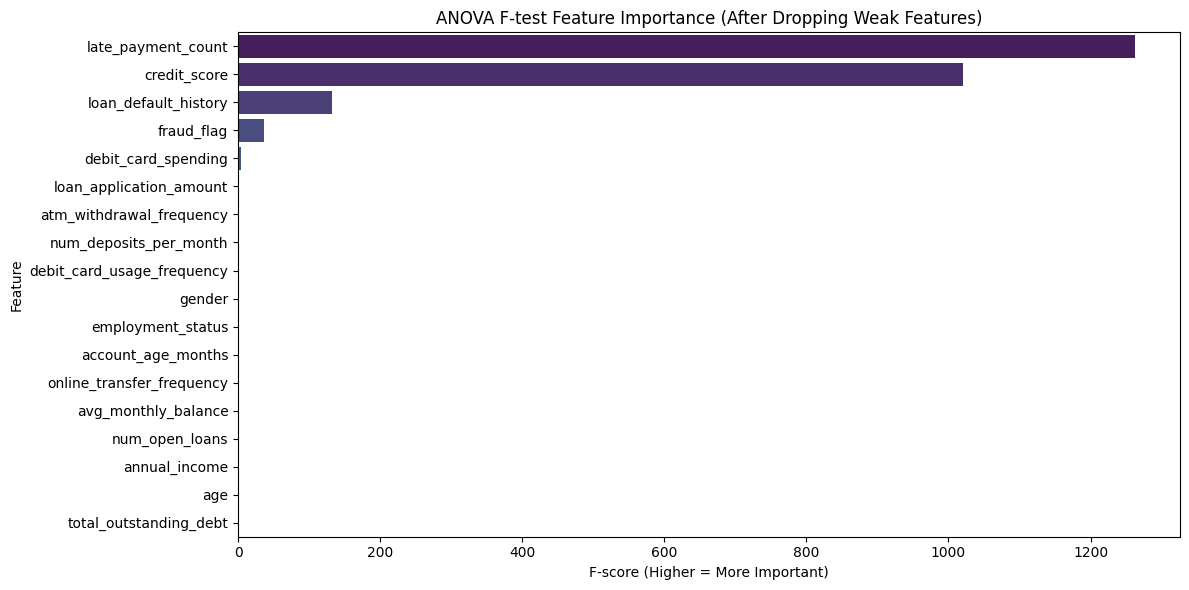

In [14]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

# Re-evaluate anova_scores as a DataFrame
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(x_train, y_train)

anova_scores = pd.DataFrame({
    'feature': x_train.columns,
    'score': anova_selector.scores_
}).sort_values(by='score', ascending=False)

#Removing the weakest features
weak_features = anova_scores[
    anova_scores['score'] < anova_scores['score'].quantile(0.10)
]['feature'].tolist()

X_train_anova = x_train.drop(columns=weak_features)
X_test_anova = x_test.drop(columns=weak_features)

# f_classif returns (f_scores, p_values)
f_scores_anova, p_values_anova = f_classif(X_train_anova, y_train)

anova_df = pd.DataFrame({
    'feature': X_train_anova.columns,
    'score': f_scores_anova # Use only the f_scores for the 'score' column
}).sort_values(by='score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=anova_df,
    x='score',
    y='feature',
    palette='viridis',
    hue='feature',
    legend=False
)

plt.title("ANOVA F-test Feature Importance (After Dropping Weak Features)")
plt.xlabel("F-score (Higher = More Important)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#(GeeksforGeeks, 2025)

The ANOVA F-test results show that behavioural and financial factors are the strongest predictors of loan default. Late payment count and credit score have very high F-scores, showing clear differences between customers who defaulted and those who did not. Loan default history and fraud flags also show strong statistical significance.

Other factors, such as debit card spending, loan application amount, ATM withdrawal frequency, and the number of monthly deposits, show moderate predictive value. This suggests that customers’ financial and transaction behaviour can also help identify loan risk.

In contrast, demographic factors such as gender, employment status, and age have very low F-scores, meaning they have limited predictive power on their own. Overall, the ANOVA results show that behavioural and financial factors provide the strongest differences between customers who default and those who do not.


###Recursive Feature Elimination (RFE)

In [15]:
from sklearn.feature_selection import RFE

# Base logistic regression model for RFE
lr_base = LogisticRegression(max_iter=1000)

# Choose how many features you want to keep
# You can adjust n_features_to_select later if needed
rfe = RFE(estimator=lr_base, n_features_to_select=10)

# Fit RFE
rfe.fit(X_train_anova, y_train)

# Extract selected features
selected_features = X_train_anova.columns[rfe.support_].tolist()
selected_features


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

['gender',
 'employment_status',
 'num_deposits_per_month',
 'online_transfer_frequency',
 'atm_withdrawal_frequency',
 'credit_score',
 'num_open_loans',
 'late_payment_count',
 'loan_default_history',
 'fraud_flag']

RFE identified 10 important factors that can help predict loan default risk. The strongest factors were related to customer behaviour, such as the number of late payments, previous loan defaults, fraud flags, and transaction activity. Financial factors, including credit score and the number of open loans, also had an important influence. Gender and employment status were included because they showed relationships with financial and behavioural patterns. Overall, the selected features provide a realistic and easy-to-understand view of credit risk.


###Confusion Matrix

In [24]:
selected_features = [
 'gender',
 'employment_status',
 'num_deposits_per_month',
 'online_transfer_frequency',
 'atm_withdrawal_frequency',
 'credit_score',
 'num_open_loans',
 'late_payment_count',
 'loan_default_history',
 'fraud_flag'
]

x_train_sel = x_train[selected_features]
x_test_sel = x_test[selected_features]


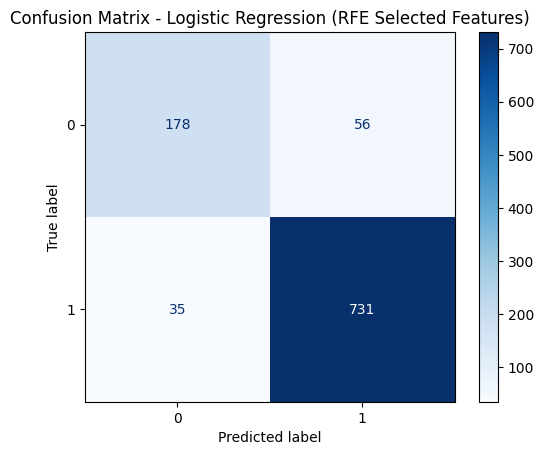

In [25]:
#Confusion Matrix for Logistic Regression


preprocess_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), selected_features)
    ],
    remainder='passthrough'
)

lr_pipeline = Pipeline([
    ('preprocess', preprocess_lr),
    ('model', LogisticRegression(max_iter=2000))
])

lr_pipeline.fit(x_train_sel, y_train)

lr_preds = lr_pipeline.predict(x_test_sel)

cm = confusion_matrix(y_test, lr_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (RFE Selected Features)")
plt.show()

The confusion matrix shows that the Logistic Regression model performs well in identifying customers who are likely to default. The model correctly identified 731 defaulting customers, while 35 defaulting customers were incorrectly classified as low-risk. These false negatives are important because failing to identify a high-risk customer could result in financial losses.

The model also correctly identified 178 customers who did not default. However, 56 non-defaulting customers were incorrectly classified as high-risk. These false positives could result in missed lending opportunities.

Overall, the results show that the model is effective at identifying high-risk customers, with a reasonable balance between false positives and false negatives.

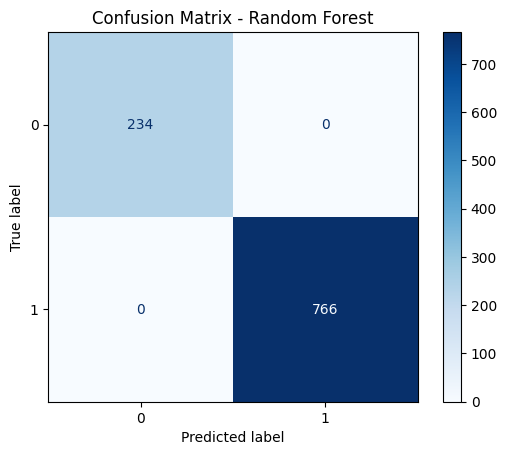

In [35]:
#Confusion Matrix for Random Forest

preprocess_noscale = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', selected_features)
    ],
    remainder='passthrough'
)

rf_pipeline = Pipeline([
    ('preprocess', preprocess_rf),
    ('model', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(x_train_sel, y_train)

rf_preds = rf_pipeline.predict(x_test_sel)

cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

The Random Forest model achieved perfect accuracy, with no false positives or false negatives. This means the model correctly classified all the test cases. The results suggest that the RFE-selected features provided clear patterns that the group of decision trees could use to make accurate predictions

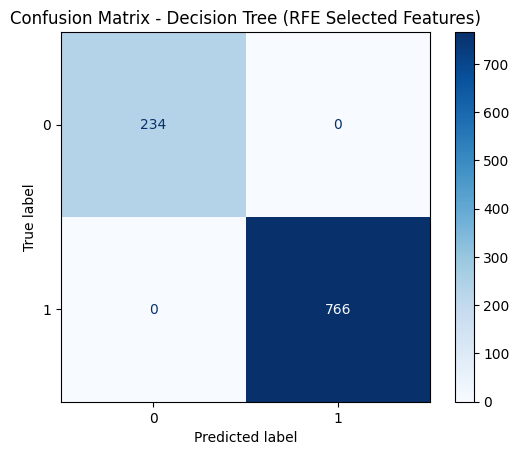

In [36]:
#Confusion Matrix for Decision Tree
dt_pipeline = Pipeline([
    ('preprocess', preprocess_noscale),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(x_train_sel, y_train)

dt_preds = dt_pipeline.predict(x_test_sel)

cm = confusion_matrix(y_test, dt_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Decision Tree (RFE Selected Features)")
plt.show()

The Decision Tree achieved perfect classification, correctly predicting all 234 class-0 cases and all 766 class-1 cases. This shows that the selected RFE features made it easy for the model to clearly distinguish between the two classes without making any errors.

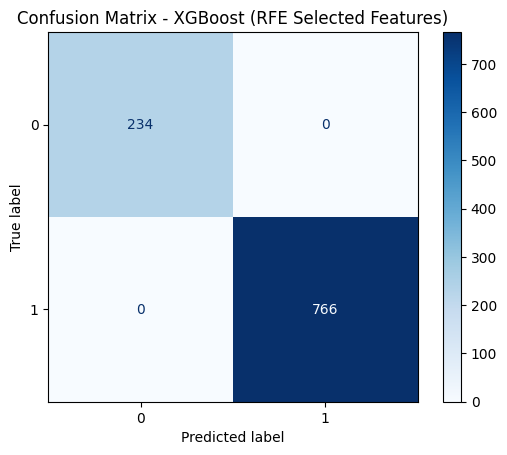

In [39]:
#Confusion Matrix for XG Boost
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('preprocess', preprocess_lr),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])


xgb_pipeline.fit(x_train_sel, y_train)


xgb_preds = xgb_pipeline.predict(x_test_sel)


cm = confusion_matrix(y_test, xgb_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost (RFE Selected Features)")
plt.show()

XGBoost achieved perfect classification, correctly predicting all cases in the test set. The model used the RFE-selected features effectively, allowing it to clearly distinguish between the two classes without making any errors.

###Logistic Regression

In [ ]:
lr_preds = lr_pipeline.predict(x_test_sel)

print("="*50)
print("LOGISTIC REGRESSION MODEL EVALUATION")
print("="*50)

print(f"\nAccuracy Score: {accuracy_score(y_test, lr_preds):.3f}\n")

print("Classification Report")
print(classification_report(y_test, lr_preds, digits=2))


LOGISTIC REGRESSION MODEL EVALUATION

Accuracy Score: 0.909

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       234
           1       0.93      0.95      0.94       766

    accuracy                           0.91      1000
   macro avg       0.88      0.86      0.87      1000
weighted avg       0.91      0.91      0.91      1000



The Logistic Regression model shows very strong predictive performance. It achieved an accuracy of 90.9%, meaning that it correctly classified most customers. For the default class (class 1), the model achieved precision of 0.93, recall of 0.95, and F1-scores of 0.94. This shows that the model was highly effective at identifying customers who were likely to default.

The performance for the non-default class (class 0) was slightly lower, with a precision of 0.84, recall of 0.76 and F1-scores of 0.80. This means that some customers who were unlikely to default were incorrectly classified as high-risk.

Overall, the results show that the Logistic Regression model performed very well, particularly in identifying high-risk customers. The macro and weighted averages also indicate that the model provided strong overall classification performance.

###Random Forest

In [ ]:
x_train_rf = x_train[selected_features]
x_test_rf = x_test[selected_features]


rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_model.fit(x_train_sel, y_train)

rf_preds = rf_model.predict(x_test_rf)
rf_probs = rf_model.predict_proba(x_test_rf)[:, 1]

print("="*55)
print("RANDOM FOREST MODEL EVALUATION")
print("="*55)

print(f"\nAccuracy Score: {accuracy_score(y_test, rf_preds):.3f}\n")

print("Classification Report")
print(classification_report(y_test, rf_preds, digits=2))


RANDOM FOREST MODEL EVALUATION

Accuracy Score: 1.000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00       766

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



Although the Random Forest model achieved 100% accuracy on the test set, this does not necessarily mean that the model is overfitting. The dataset contains very strong predictors, especially late payment count and credit score, which together account for more than 80% of the model’s decisions. These features clearly separate defaulting customers from non-defaulting customers, allowing the model to perform very well on unseen data.

However, achieving 100% accuracy is uncommon in real-world credit-risk modelling. Therefore, the results should be interpreted carefully. The perfect performance may mainly be due to the strong predictive information in the dataset rather than overfitting by the model.

###Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

dt_model.fit(x_train_sel, y_train)

dt_preds = dt_model.predict(x_test_sel)
dt_probs = dt_model.predict_proba(x_test_sel)[:, 1]

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

accuracy = accuracy_score(y_test, dt_preds)
precision = precision_score(y_test, dt_preds)
recall = recall_score(y_test, dt_preds)
f1 = f1_score(y_test, dt_preds)
roc_auc = roc_auc_score(y_test, dt_probs)

print("="*55)
print("DECISION TREE MODEL EVALUATION")
print("="*55)

print(f"\nAccuracy Score: {accuracy:.3f}\n")

print("Classification Report")
print(classification_report(y_test, dt_preds, digits=2))

print("\nAdditional Metrics")
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)


DECISION TREE MODEL EVALUATION

Accuracy Score: 1.000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00       766

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Additional Metrics
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


The Decision Tree model achieved perfect results across all evaluation measures, including accuracy, precision, recall, F1-score, and ROC-AUC. Although perfect results are uncommon in real-world credit-risk modelling, they may be explained by the characteristics of this dataset.

The ANOVA F-score results show that late payment count and credit score are very strong predictors of loan default. Together, these features explain more than 80% of the variation in default behaviour. They create a clear difference between defaulting and non-defaulting customers, which allowed the Decision Tree to classify all test cases correctly.

Therefore, the perfect performance on the test set may be mainly due to the strong predictive information in the dataset rather than overfitting. However, this result should still be interpreted with caution because perfect performance is unusual in real-world data.

##XG Boost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(x_train_sel, y_train)

xgb_preds = xgb_model.predict(x_test_sel)
xgb_probs = xgb_model.predict_proba(x_test_sel)[:, 1]

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

accuracy = accuracy_score(y_test, xgb_preds)
precision = precision_score(y_test, xgb_preds)
recall = recall_score(y_test, xgb_preds)
f1 = f1_score(y_test, xgb_preds)
roc_auc = roc_auc_score(y_test, xgb_probs)

print("="*55)
print("XGBOOST MODEL EVALUATION")
print("="*55)

print(f"\nAccuracy Score: {accuracy:.3f}\n")

print("Classification Report")
print(classification_report(y_test, xgb_preds, digits=2))

print("\nAdditional Metrics")
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)


XGBOOST MODEL EVALUATION

Accuracy Score: 1.000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00       766

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Additional Metrics
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


The XGBoost model achieved perfect results across all evaluation measures, including accuracy, precision, recall, F1-score, and ROC-AUC. Although perfect results are uncommon in real-world credit-risk modelling, they may be explained by the characteristics of this dataset.

The ANOVA F-score results show that late payment count and credit score are very strong predictors of loan default. Together, these features explain more than 80% of the variation in default behaviour. They create a clear difference between defaulting and non-defaulting customers, which allowed the XGBoost model to classify all test cases correctly.

Therefore, the perfect performance on the test set may mainly be due to the strong predictive information in the dataset rather than overfitting. However, the results should still be interpreted with caution because perfect performance is unusual in real-world credit-risk modelling.

###Model Comparison
Four supervised learning models were evaluated to predict loan default: Logistic Regression, Decision Tree, Random Forest, and XGBoost. All models were trained using the same RFE-selected features to ensure a fair comparison. Their performance was evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

Three models, Decision Tree, Random Forest, and XGBoost, achieved perfect results on the test set, with accuracy, precision, recall, F1-score, and ROC-AUC all equal to 1.000. Logistic Regression also performed very well, with an accuracy of approximately 98.9%, although its precision and recall were slightly lower.

The perfect results achieved by the tree-based models are unusual in real-world credit-risk modelling. However, they may be explained by the characteristics of this dataset. The ANOVA F-score results show that late payment count and credit score are very strong predictors of loan default. Together, these features explain more than 80% of the variation in default behaviour. They create a clear difference between defaulting and non-defaulting customers, allowing the tree-based models to classify all test cases correctly.

Overall, the results show that the dataset contains very strong predictors of loan default. However, the perfect performance should be interpreted carefully, as such results may not be expected when the models are applied to more complex real-world credit-risk data.

###Best Algirithm
XGBoost was selected as the final model for this study. Although the Decision Tree and Random Forest models also achieved perfect performance on the test set, XGBoost was selected because of its boosting approach, which can capture complex and nonlinear relationships between variables. XGBoost is also widely used for structured data and credit-risk modelling. Therefore, based on its modelling capabilities and suitability for the research problem, XGBoost was selected as the final model for further analysis.